# Mapas del Informe — PMA Valparaíso

Genera los 7 mapas para el informe del modelo de optimización de PMAs post-terremoto Mw≥8, Región de Valparaíso.  
Instancia: 36 comunas · 85 centros candidatos · 32 hospitales · horizonte 7 días.

Las imágenes se guardan en `mapas/` (PNG 300 dpi).


---

## Configuración e imports

Carga las librerías necesarias y define la paleta de colores usada en todos los mapas para mantener consistencia visual.

**Dependencias:** `geopandas`, `matplotlib`, `shapely`, `pandas`, `numpy`. `contextily` es opcional (basemap satelital); si no está instalado, los mapas usan fondo blanco.

**`save_fig`** guarda cada figura en `mapas/` a 300 dpi y la muestra inline en el notebook.


In [264]:
# ── 0. Setup ───────────────────────────────────────────────────────────────────
%matplotlib inline

import json
import unicodedata
from pathlib import Path

import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely
from shapely.geometry import Point

try:
    import contextily as ctx
    HAS_CONTEXTILY = True
except ImportError:
    HAS_CONTEXTILY = False
    print("contextily no disponible — mapas sin basemap satelital")

Path("mapas").mkdir(exist_ok=True)

# ── Colores de fondo y bordes ──────────────────────────────────────────────────
FONDO_COMUNAS  = "#f6f4f1"
BORDE_COMUNAS  = "#aaaaaa"
FONDO_CUBIERTA = "#c8e6c9"
FONDO_SIN_COB  = "#ffccbc"

# ── Colores de marcadores por tipo de nodo ────────────────────────────────────
COLOR_COLEGIO  = "#1565C0"
COLOR_RECINTO  = "#E65100"
COLOR_HOSPITAL = "#B71C1C"
COLOR_ACTIVO   = "#2E7D32"
COLOR_INACTIVO = "#90A4AE"

# ── Colores auxiliares ─────────────────────────────────────────────────────────
COLOR_BUFFER    = "steelblue"   # buffer de cobertura (Mapa 3)
COLOR_LABEL     = "#222222"     # texto de etiquetas de comunas
COLOR_CONNECTOR = "#282828"     # líneas conectoras de etiquetas
COLOR_UNCOV     = "red"         # borde comunas sin cobertura (Mapa 5)

# ── Categorías de riesgo hospitalario (única fuente de verdad) ─────────────────
CAT_COLORS_HOSP = {
    "tsunami_flood":    ("#B71C1C", "Zona inundación tsunami (Cap=0)"),
    "tsunami_vertical": ("#E53935", "Evacuación vertical tsunami"),
    "antiguo_alto":     ("#F57C00", "Edificio antiguo en zona alta"),
    "bajo_publico":     ("#FDD835", "Hospital bajo riesgo (público)"),
    "privado":          ("#66BB6A", "Clínica privada"),
    "moderno_alto":     ("#1E88E5", "Edificio moderno en zona alta"),
}

# ── Tamaños de marcadores (pt²) ────────────────────────────────────────────────
MS_COLEGIO  = 60
MS_RECINTO  = 60
MS_HOSPITAL = 60    # hexágono a tamaño fijo (cuando no se escala por camas)
MS_ACTIVO   = 60    # centros activos en mapas de solución
MS_HOSP_MIN = 25    # mínimo para hospitales escalados por camas
MS_HOSP_MAX = 300   # máximo para hospitales escalados por camas
MS_HOSP_SCL = 300   # factor: camas/max_camas * MS_HOSP_SCL → clipeado a [MIN, MAX]

# Tamaños en leyenda
MS_LEG      = 10    # círculo/cuadrado/hexágono en leyenda
MS_LEG_STAR = 14    # estrella (necesita ser más grande para verse igual)

# ── Transparencias ─────────────────────────────────────────────────────────────
ALPHA_CENTRO   = 0.85
ALPHA_HOSPITAL = 0.85
ALPHA_ACTIVO   = 0.90
ALPHA_BUFFER   = 0.12

# ── Grosores de línea ──────────────────────────────────────────────────────────
LW_MARKER    = 0.6   # borde uniforme de todos los marcadores
LW_CONNECTOR = 0.7   # líneas conectoras de etiquetas
LW_UNCOV     = 2.5   # borde de comunas sin cobertura (Mapa 5)

# ── Tipografía ─────────────────────────────────────────────────────────────────
FS_TITLE    = 12
FS_SUPTITLE = 13
FS_SUBTITLE = 11
FS_LEGEND   = 9
FS_LEG_TTL  = 9
FS_LABEL    = 6.5

# ── Tamaños de figura ──────────────────────────────────────────────────────────
FIGSIZE_1 = (11, 9)   # figura individual
FIGSIZE_2 = (18, 8)   # figura de dos paneles lado a lado

# ── Z-orders ───────────────────────────────────────────────────────────────────
Z_COMUNAS  = 1
Z_BUFFER   = 2
Z_HOSPITAL = 3
Z_CENTRO   = 4
Z_LABEL    = 10

# ── AJUSTE DE BUFFER ──────────────────────────────────────────────────────────
# Cambia este valor para probar distintos tamaños de buffer outward (en metros).
# El buffer expande cada polígono de comuna, tapando los gaps entre vecinas.
# Sugeridos: 200, 250, 300, 400. En 0 no se aplica buffer.
BUFFER_M = 500
# ─────────────────────────────────────────────────────────────────────────────

def norm(s):
    s = str(s).strip().upper()
    s = unicodedata.normalize('NFD', s)
    return ''.join(c for c in s if unicodedata.category(c) != 'Mn')

def _apply_buffer(gdf):
    """Aplica BUFFER_M metros outward en UTM 19S para tapar gaps entre comunas."""
    if BUFFER_M <= 0:
        return gdf
    gdf2 = gdf.copy()
    gdf2["geometry"] = gdf.to_crs("EPSG:32719").geometry.buffer(BUFFER_M).to_crs(gdf.crs)
    return gdf2

def plot_comunas(ax, gdf, linewidth=0.8, edgecolor=None, zorder=1, **kwargs):
    ec = edgecolor if edgecolor is not None else BORDE_COMUNAS
    gdf_buf = _apply_buffer(gdf)
    gdf_buf.plot(ax=ax, edgecolor="none", zorder=zorder, **kwargs)
    outline_kw = {k: v for k, v in kwargs.items()
                  if k not in ("column", "cmap", "color", "legend", "legend_kwds",
                               "vmin", "vmax", "scheme", "categorical", "missing_kwds",
                               "categories", "classification_kwds")}
    gdf.plot(ax=ax, color="none", edgecolor=ec, linewidth=linewidth,
             zorder=zorder + 1, **outline_kw)

def save_fig(fig, nombre):
    ruta = f"mapas/{nombre}.png"
    fig.savefig(ruta, dpi=300, bbox_inches="tight", facecolor=FONDO_COMUNAS)
    plt.show()
    plt.close(fig)
    print(f"Guardado: {ruta}")

def label_comunas(ax, min_pob=60000):
    for _, row in gdf_comunas[gdf_comunas["poblacion"] >= min_pob].iterrows():
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        ax.annotate(row["nombre"].title(), xy=(cx, cy), fontsize=FS_LABEL,
                    ha="center", va="center", color=COLOR_LABEL, zorder=Z_LABEL)

print(f"Setup OK  |  BUFFER_M = {BUFFER_M} m")


contextily no disponible — mapas sin basemap satelital
Setup OK  |  BUFFER_M = 500 m


---

## Carga de datos

Lee todos los archivos de entrada una sola vez; el resto de las celdas los reutilizan.

| Variable             | Archivo fuente                                           | Descripción                                                                            |
| -------------------- | -------------------------------------------------------- | -------------------------------------------------------------------------------------- |
| `gdf_comunas`        | `Datos/comunas.geojson` + `Datos/data/nodos_comunas.csv` | 36 polígonos de comunas de la Región de Valparaíso con id, nombre y población          |
| `gdf_centros`        | `Datos/data/nodos_centros.csv`                           | 85 centros candidatos para PMA (70 colegios + 15 estadios) con coordenadas y capacidad |
| `gdf_hosp`           | `Datos/data/nodos_hospitales.csv`                        | 32 hospitales con coordenadas, camas base, altitud y categoría de riesgo               |
| `df_tiempos`         | `Datos/data/tiempos_ij.csv`                              | Tiempos de viaje T_ij en minutos entre cada par (comuna i, centro j)                   |
| `df_cob_base`        | `Datos/data/cobertura_ij.csv`                            | Matriz binaria A_ij = 1 si T_ij ≤ T_max (generada con T_max=30 min)                    |
| `df_act_base`        | `resultados/T30_H100/resultado_activacion.csv`           | Variables z_jt del modelo: qué centros abre el modelo en cada día (escenario base)     |
| `df_act_t60h100/150` | `resultados/T60_H100(150)/resultado_activacion.csv`      | Ídem para escenarios de sensibilidad T_max=60 min                                      |

**Nota técnica:** el GeoJSON se lee con `shapely.from_geojson()` en lugar del parser por defecto de geopandas porque la versión instalada de shapely 2.x tiene un bug al construir `MultiPolygon` desde coordenadas anidadas. Esta lectura manual es 100% compatible.


In [265]:
# ── 1. Carga de datos ──────────────────────────────────────────────────────────

# 1a. GeoJSON — leer manualmente con shapely.from_geojson (compatibilidad shapely 2.x)
#     El archivo fue reparado con snap(tol=0.0001°) + make_valid para cerrar
#     los gaps topológicos entre comunas adyacentes.
with open("Datos/comunas.geojson", encoding="utf-8") as f:
    geojson_data = json.load(f)

rows_geo = []
for feat in geojson_data["features"]:
    if feat["geometry"]:
        geom = shapely.from_geojson(json.dumps(feat["geometry"]))
        row = feat["properties"].copy()
        row["geometry"] = geom
        rows_geo.append(row)

gdf_chile = gpd.GeoDataFrame(rows_geo, crs="EPSG:4326")
gdf_reg5 = gdf_chile[gdf_chile["codregion"] == 5].copy()
gdf_reg5["nombre_norm"] = gdf_reg5["Comuna"].apply(norm)

# 1b. Nodos del modelo
df_comunas = pd.read_csv("Datos/data/nodos_comunas.csv")
df_centros = pd.read_csv("Datos/data/nodos_centros.csv")
df_hospitales = pd.read_csv("Datos/data/nodos_hospitales.csv")
df_comunas["nombre_norm"] = df_comunas["nombre"].apply(norm)

# 1c. Join comunas modelo con polígonos
gdf_comunas = gpd.GeoDataFrame(
    df_comunas.merge(
        gdf_reg5[["nombre_norm", "geometry", "cod_comuna"]],
        on="nombre_norm", how="left",
    ),
    geometry="geometry", crs="EPSG:4326",
)
assert gdf_comunas["geometry"].isna().sum() == 0, "Hay comunas sin geometría!"

# 1d. Tiempos y cobertura base
df_tiempos = pd.read_csv("Datos/data/tiempos_ij.csv")
df_cob_base = pd.read_csv("Datos/data/cobertura_ij.csv")

# 1e. Activaciones
df_act_base = pd.read_csv("resultados/T30_H100/resultado_activacion.csv")
df_act_t60h100 = pd.read_csv("resultados/T60_H100/resultado_activacion.csv")
df_act_t60h150 = pd.read_csv("resultados/T60_H150/resultado_activacion.csv")

# GeoDataFrames de puntos
gdf_centros = gpd.GeoDataFrame(
    df_centros,
    geometry=gpd.points_from_xy(df_centros["lon"], df_centros["lat"]),
    crs="EPSG:4326",
)
gdf_hosp = gpd.GeoDataFrame(
    df_hospitales,
    geometry=gpd.points_from_xy(df_hospitales["lon"], df_hospitales["lat"]),
    crs="EPSG:4326",
)

print(f"Comunas modelo: {len(gdf_comunas)}")
print(
    f"Centros candidatos: {len(gdf_centros)}  (tipos: {df_centros['tipo'].value_counts().to_dict()})")
print(f"Hospitales: {len(gdf_hosp)}")

Comunas modelo: 36
Centros candidatos: 85  (tipos: {'colegio': 70, 'estadio': 15})
Hospitales: 32


---

## Mapa 1 — Instancia: red completa de candidatos

> **Uso en informe:** Slide 12 — "Mapa de cobertura de la red"

### Qué muestra

La geografía completa del problema antes de resolver: las 36 comunas continentales de la Región de Valparaíso (polígonos grises) con todos los nodos del modelo superpuestos.

### Simbología

| Símbolo       | Qué representa                                                                  |
| ------------- | ------------------------------------------------------------------------------- |
| Polígono gris | Comuna del modelo (zona de demanda i)                                           |
| ● Azul        | Colegio candidato a PMA (70 recintos educacionales filtrados de MINEDUC)        |
| ★ Naranja     | Estadio/recinto deportivo candidato (15 instalaciones deportivas de alto aforo) |
| ✚ Rojo        | Hospital de la red de salud (32 establecimientos con camas registradas)         |

### Datos usados

- Centros candidatos filtrados por capacidad mínima (≥ 600 m² uso refugio, según OGUC Art. 4.8.2 a 3.5 m²/persona).
- Hospitales parametrizados con capacidad variable por día (degradación de red post-sismo modelada explícitamente en Cap_1..Cap_7).
- Solo se etiquetan comunas con población ≥ 60.000 hab. para no saturar el mapa.

### Interpretación

La concentración de candidatos en el arco costero (Valparaíso, Viña del Mar, San Antonio) refleja la distribución urbana de la región. Las comunas interiores (Los Andes, San Felipe, Putaendo) tienen pocos candidatos y quedan expuestas a limitaciones de cobertura, como se analiza en el Mapa 5.


Mapa 1: Instancia


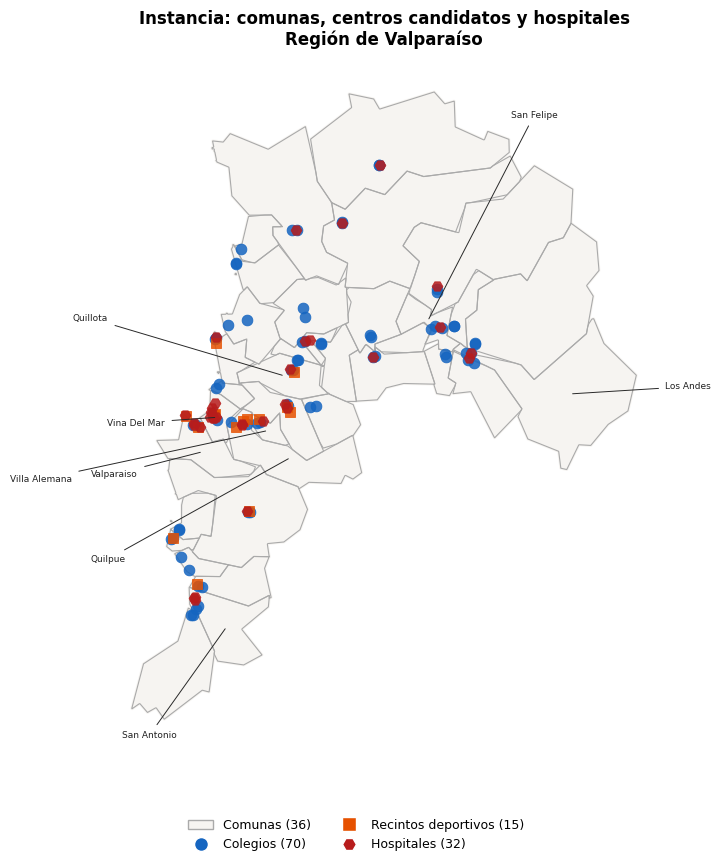

  mapas/01/instancia_con_linea.png


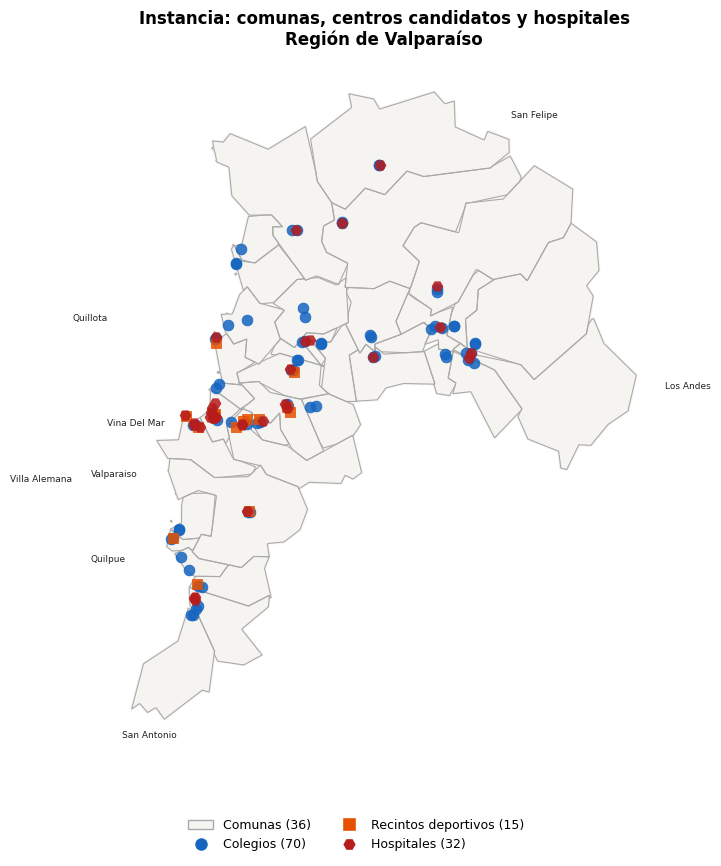

  mapas/01/instancia_sin_linea.png


In [266]:
# ── MAPA 1: Instancia (2 versiones: con/sin línea) ───────────────────────────
Path("mapas/01/").mkdir(parents=True, exist_ok=True)

print("Mapa 1: Instancia")
bounds = gdf_comunas.total_bounds
colegios = gdf_centros[gdf_centros["tipo"] == "colegio"]
recintos = gdf_centros[gdf_centros["tipo"] != "colegio"]

for linea in (True, False):
    fig, ax = plt.subplots(figsize=FIGSIZE_1)

    plot_comunas(ax, gdf_comunas, color=FONDO_COMUNAS)

    colegios.plot(ax=ax, color=COLOR_COLEGIO, marker="o", markersize=MS_COLEGIO,
                  alpha=ALPHA_CENTRO, zorder=Z_CENTRO, linewidth=LW_MARKER)

    recintos.plot(ax=ax, color=COLOR_RECINTO, marker="s", markersize=MS_RECINTO,
                  alpha=ALPHA_CENTRO, zorder=Z_CENTRO + 1, linewidth=LW_MARKER)

    gdf_hosp.plot(ax=ax, color=COLOR_HOSPITAL, marker="H", markersize=MS_HOSPITAL,
                  alpha=ALPHA_HOSPITAL, zorder=Z_CENTRO + 2, linewidth=LW_MARKER)

    _add_labels(ax, bounds, linea=linea)

    ax.set_axis_off()
    ax.set_title("Instancia: comunas, centros candidatos y hospitales\nRegión de Valparaíso",
                 fontsize=FS_TITLE, fontweight="bold", pad=10)

    ax.legend(
        handles=[
            mpatches.Patch(facecolor=FONDO_COMUNAS, edgecolor=BORDE_COMUNAS,
                           label=f"Comunas ({len(gdf_comunas)})"),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_COLEGIO,
                       markersize=MS_LEG, label=f"Colegios ({len(colegios)})"),
            plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=COLOR_RECINTO,
                       markersize=MS_LEG, label=f"Recintos deportivos ({len(recintos)})"),
            plt.Line2D([0], [0], marker='H', color='w', markerfacecolor=COLOR_HOSPITAL,
                       markersize=MS_LEG, label=f"Hospitales ({len(gdf_hosp)})"),
        ],
        loc="lower center",
        bbox_to_anchor=(0.45, -0.15),
        fontsize=FS_LEGEND,
        frameon=False,
        borderaxespad=0,
        ncols=2,
    )

    ruta = f"mapas/01/instancia_{'con' if linea else 'sin'}_linea.png"
    fig.savefig(ruta, dpi=300, bbox_inches="tight", facecolor=FONDO_COMUNAS)
    plt.show()
    plt.close(fig)
    print(f"  {ruta}")

---

## Mapa 1b — Instancia: nodos por tipo (3 imágenes separadas)

> **Uso en informe:** Slide 12 — detalle de cada tipo de instalación

### Qué muestra

Tres mapas independientes, cada uno con un tipo de nodo diferente:

| Archivo              | Contenido                                              |
| -------------------- | ------------------------------------------------------ |
| `01b_colegios.png`   | 70 colegios candidatos a PMA (azul ●)                  |
| `01b_recintos.png`   | 15 estadios/recintos deportivos candidatos (naranja ★) |
| `01b_hospitales.png` | 32 hospitales coloreados por categoría de riesgo       |

### Labels de comunas

Las comunas con población ≥ 60.000 hab. se etiquetan **fuera del mapa**, con una línea que conecta el texto al centroide de la comuna. La posición del texto se calcula proyectando el vector (centro_del_mapa → centroide) un factor 1.38× hacia afuera.


Colegios:


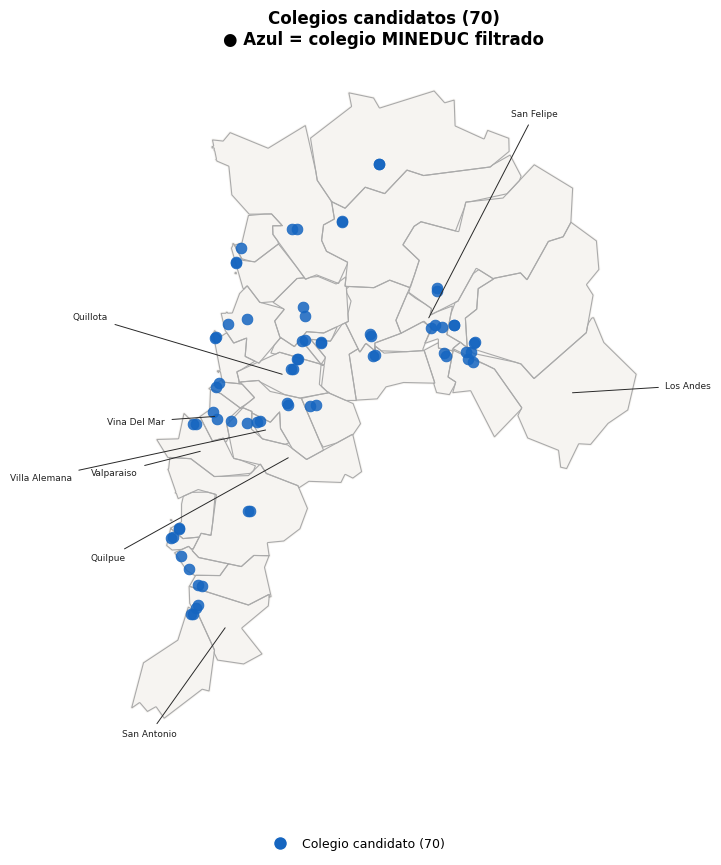

  mapas/01b/colegios_con_linea.png


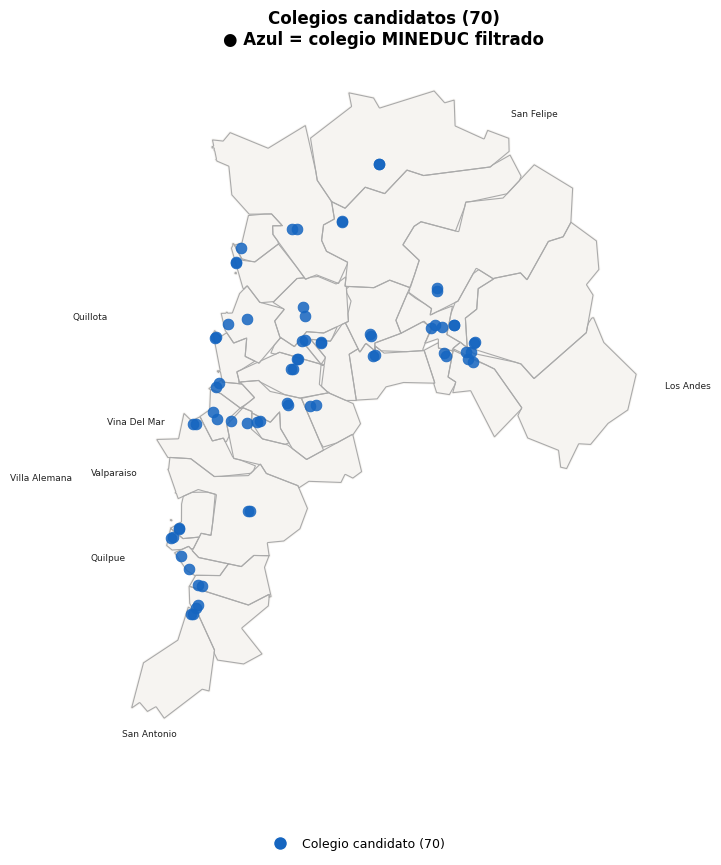

  mapas/01b/colegios_sin_linea.png
Recintos:


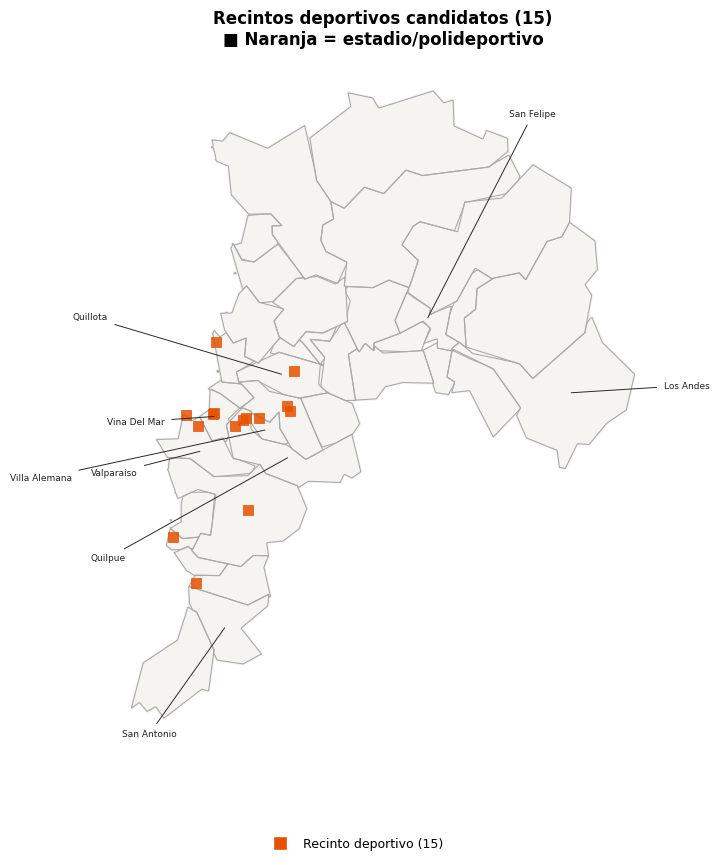

  mapas/01b/recintos_con_linea.png


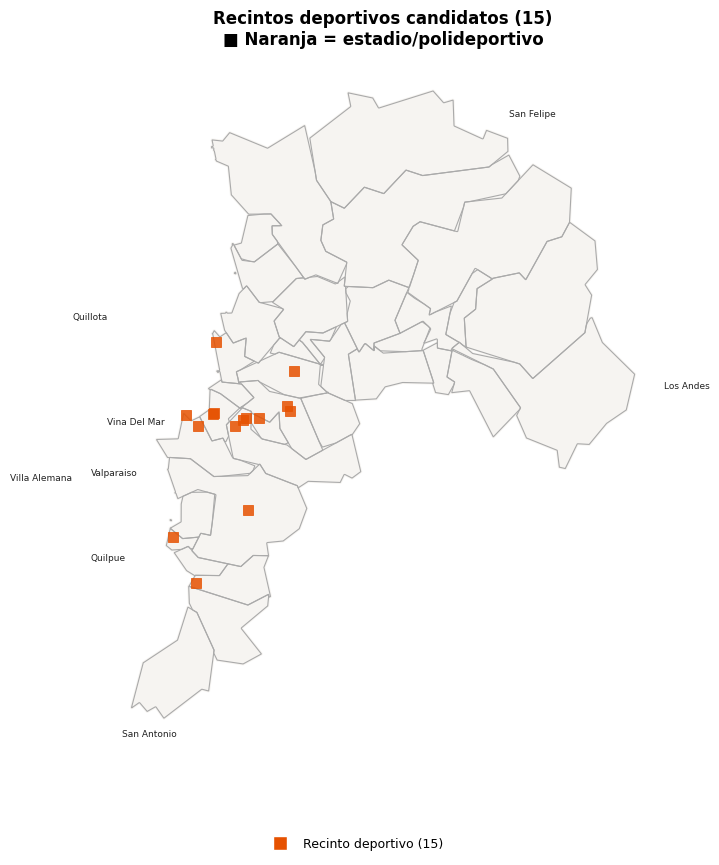

  mapas/01b/recintos_sin_linea.png
Hospitales:


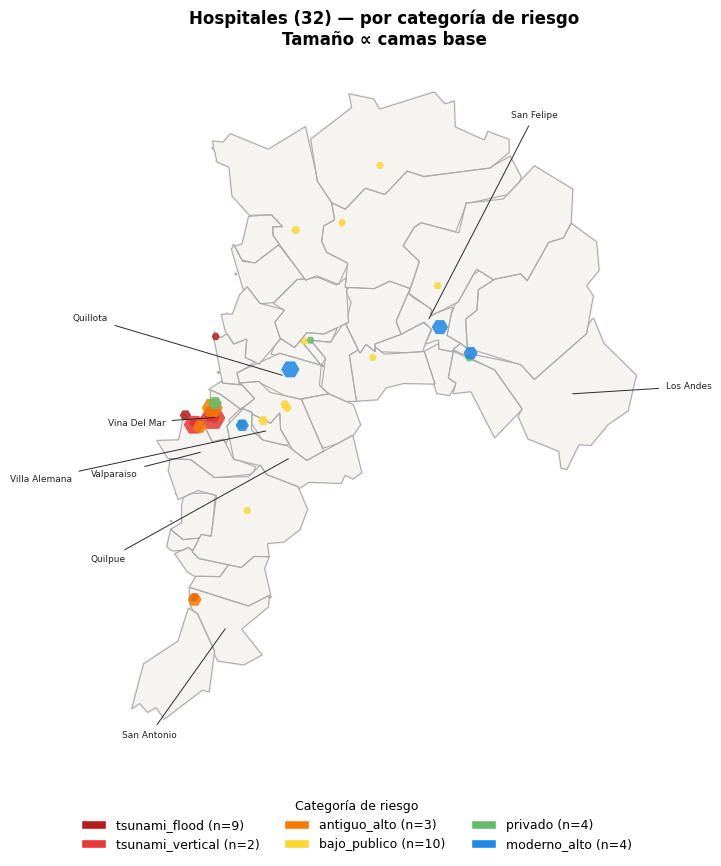

  mapas/01b/hospitales_con_linea.png


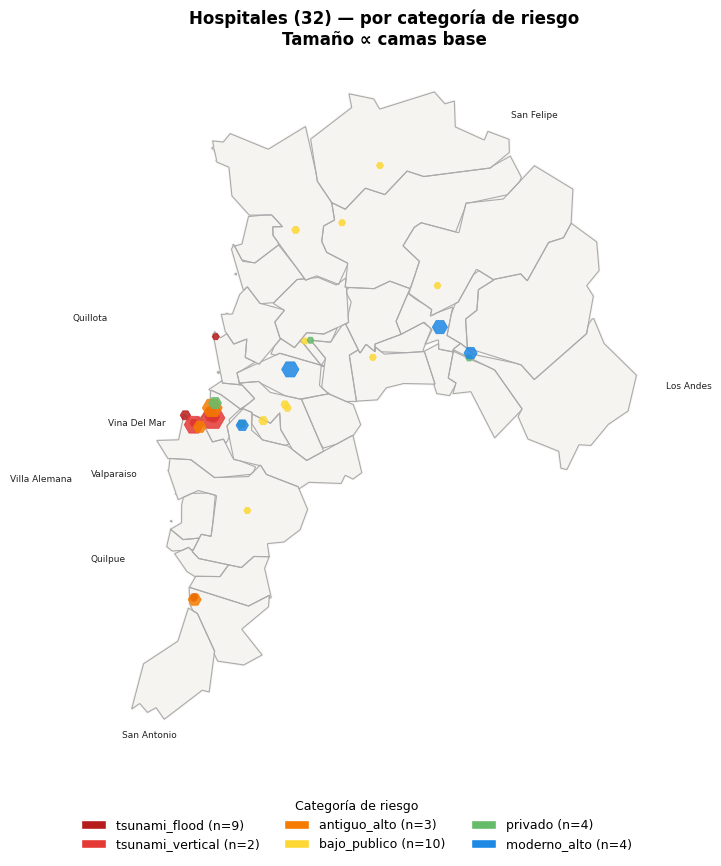

  mapas/01b/hospitales_sin_linea.png


In [267]:
# ── MAPA 1b: 3 mapas × 2 versiones (con/sin línea) → mapas/01b/ ──────────────
Path("mapas/01b").mkdir(parents=True, exist_ok=True)

colegios = gdf_centros[gdf_centros["tipo"] == "colegio"]
recintos = gdf_centros[gdf_centros["tipo"] != "colegio"]

# ── Escala de labels por comuna ────────────────────────────────────────────────
comunas_grandes = gdf_comunas[gdf_comunas["poblacion"] >= 60000].copy()
LABEL_SCALE = {row["nombre"]: 1.38 for _, row in comunas_grandes.iterrows()}
LABEL_SCALE["LOS ANDES"] = 1.65
LABEL_SCALE["QUILLOTA"] = 3.0
LABEL_SCALE["QUILPUE"] = 3.0
LABEL_SCALE["SAN ANTONIO"] = 1.5
LABEL_SCALE["SAN FELIPE"] = 3.5
LABEL_SCALE["VALPARAISO"] = 1.5
LABEL_SCALE["VILLA ALEMANA"] = 3.0
LABEL_SCALE["VINA DEL MAR"] = 1.5


def _label_fuera(ax, name, nombre_key, cx, cy, bounds, linea=True, fontsize=FS_LABEL):
    scale = LABEL_SCALE.get(nombre_key, 1.38)
    minx, miny, maxx, maxy = bounds
    mcx, mcy = (minx + maxx) / 2, (miny + maxy) / 2
    dx, dy = cx - mcx, cy - mcy
    tx, ty = mcx + dx * scale, mcy + dy * scale
    kw = dict(fontsize=fontsize, ha="center", va="center",
              color=COLOR_LABEL, zorder=Z_LABEL)
    if linea:
        kw["arrowprops"] = dict(arrowstyle="-", color=COLOR_CONNECTOR,
                                linewidth=LW_CONNECTOR, shrinkA=3, shrinkB=3)
    ax.annotate(name, xy=(cx, cy), xytext=(tx, ty), **kw)


def _add_labels(ax, bounds, linea=True):
    for _, row in comunas_grandes.iterrows():
        _label_fuera(ax, row["nombre"].title(), row["nombre"],
                     row.geometry.centroid.x, row.geometry.centroid.y,
                     bounds, linea=linea)


def _save_sub(fig, nombre):
    ruta = f"mapas/01b/{nombre}.png"
    fig.savefig(ruta, dpi=300, bbox_inches="tight", facecolor=FONDO_COMUNAS)
    plt.show()
    plt.close(fig)
    print(f"  {ruta}")


bounds = gdf_comunas.total_bounds

# ══ Colegios ══════════════════════════════════════════════════════════════════
print("Colegios:")
for linea in (True, False):
    fig, ax = plt.subplots(figsize=FIGSIZE_1)
    plot_comunas(ax, gdf_comunas, color=FONDO_COMUNAS)
    colegios.plot(ax=ax, color=COLOR_COLEGIO, marker="o", markersize=MS_COLEGIO,
                  alpha=ALPHA_CENTRO, zorder=Z_CENTRO, linewidth=LW_MARKER)
    _add_labels(ax, bounds, linea=linea)
    ax.set_axis_off()
    ax.set_title(f"Colegios candidatos ({len(colegios)})\n● Azul = colegio MINEDUC filtrado",
                 fontsize=FS_TITLE, fontweight="bold", pad=10)
    ax.legend(handles=[plt.Line2D([0], [0], marker="o", color="w",
                                  markerfacecolor=COLOR_COLEGIO, markersize=MS_LEG,
                                  label=f"Colegio candidato ({len(colegios)})")],
              loc="lower center", bbox_to_anchor=(0.45, -0.15),
              fontsize=FS_LEGEND, frameon=False, borderaxespad=0)
    _save_sub(fig, f"colegios_{'con' if linea else 'sin'}_linea")

# ══ Recintos deportivos ═══════════════════════════════════════════════════════
print("Recintos:")
for linea in (True, False):
    fig, ax = plt.subplots(figsize=FIGSIZE_1)
    plot_comunas(ax, gdf_comunas, color=FONDO_COMUNAS)
    recintos.plot(ax=ax, color=COLOR_RECINTO, marker="s", markersize=MS_RECINTO,
                  alpha=ALPHA_CENTRO, zorder=Z_CENTRO, linewidth=LW_MARKER)
    _add_labels(ax, bounds, linea=linea)
    ax.set_axis_off()
    ax.set_title(f"Recintos deportivos candidatos ({len(recintos)})\n■ Naranja = estadio/polideportivo",
                 fontsize=FS_TITLE, fontweight="bold", pad=10)
    ax.legend(
        handles=[plt.Line2D([0], [0], marker="s", color="w",
                 markerfacecolor=COLOR_RECINTO, markersize=MS_LEG,
                 label=f"Recinto deportivo ({len(recintos)})")],
        loc="lower center", bbox_to_anchor=(0.45, -0.15),
        fontsize=FS_LEGEND, frameon=False, borderaxespad=0)
    _save_sub(fig, f"recintos_{'con' if linea else 'sin'}_linea")

# ══ Hospitales ════════════════════════════════════════════════════════════════
print("Hospitales:")
hosp_legend = [
    mpatches.Patch(facecolor=color, edgecolor="white",
                   label=f"{cat} (n={len(gdf_hosp[gdf_hosp['categoria'] == cat])})")
    for cat, (color, _) in CAT_COLORS_HOSP.items()
    if len(gdf_hosp[gdf_hosp["categoria"] == cat]) > 0
]
for linea in (True, False):
    fig, ax = plt.subplots(figsize=FIGSIZE_1)
    plot_comunas(ax, gdf_comunas, color=FONDO_COMUNAS)
    for cat, (color, _) in CAT_COLORS_HOSP.items():
        subset = gdf_hosp[gdf_hosp["categoria"] == cat]
        if len(subset) == 0:
            continue
        sizes = np.clip(subset["camas_base"] / gdf_hosp["camas_base"].max() * MS_HOSP_SCL,
                        MS_HOSP_MIN, MS_HOSP_MAX)
        subset.plot(ax=ax, color=color, marker="H", markersize=sizes.values,
                    alpha=ALPHA_HOSPITAL, zorder=Z_HOSPITAL, linewidth=LW_MARKER)
    _add_labels(ax, bounds, linea=linea)
    ax.set_axis_off()
    ax.set_title(f"Hospitales ({len(gdf_hosp)}) — por categoría de riesgo\nTamaño ∝ camas base",
                 fontsize=FS_TITLE, fontweight="bold", pad=10)
    ax.legend(handles=hosp_legend,
              title="Categoría de riesgo", title_fontsize=FS_LEG_TTL,
              loc="lower center", bbox_to_anchor=(0.45, -0.15),
              fontsize=FS_LEGEND, frameon=False, borderaxespad=0, ncols=3)
    _save_sub(fig, f"hospitales_{'con' if linea else 'sin'}_linea")

---

## Mapa 2 — Solución óptima: evolución temporal

> **Uso en informe:** Slides 13–14 — Resultados del modelo

### Qué muestra

La solución del modelo de optimización en dos instantes clave del horizonte de 7 días, para el **escenario base (T_max=30 min, H_t×1.0)**:

- **Día 1:** Apertura inicial — el modelo activa los primeros centros con los recursos médicos disponibles (H_1=19 equipos, MaxC_1=4).
- **Día 5 (peak):** Despliegue máximo — se alcanza el número máximo de centros simultáneos (MaxC_5=19).

### Simbología

| Símbolo        | Qué representa                           |
| -------------- | ---------------------------------------- |
| ● Verde grande | Centro activo ese día (z_jt = 1)         |
| ★ Verde grande | Estadio activo ese día                   |
| ● Gris pequeño | Centro candidato no seleccionado ese día |
| ✚ Rojo         | Hospital (referencia fija)               |

### Ajustes del modelo

- `MaxC_t` limita cuántos centros pueden operar simultáneamente: [4, 8, 11, 15, 19, 19, 19].
- `H_t` fija los equipos médicos disponibles cada día: [19, 32, 55, 78, 93, 104, 112] (escenario intermedio ×1.892 para 36 comunas).
- `L=3` días mínimo de operación: un centro que abre no puede cerrar antes de 3 días.

### Interpretación

El modelo prioriza el arco costero en los primeros días por densidad de demanda y accesibilidad. El gradual aumento de centros activos sigue la curva de disponibilidad de recursos de respuesta post-sismo. La brecha entre día 1 y día 5 muestra el ramp-up logístico modelado explícitamente.


Mapa 2: Solución base (Día 1 y Día 5)


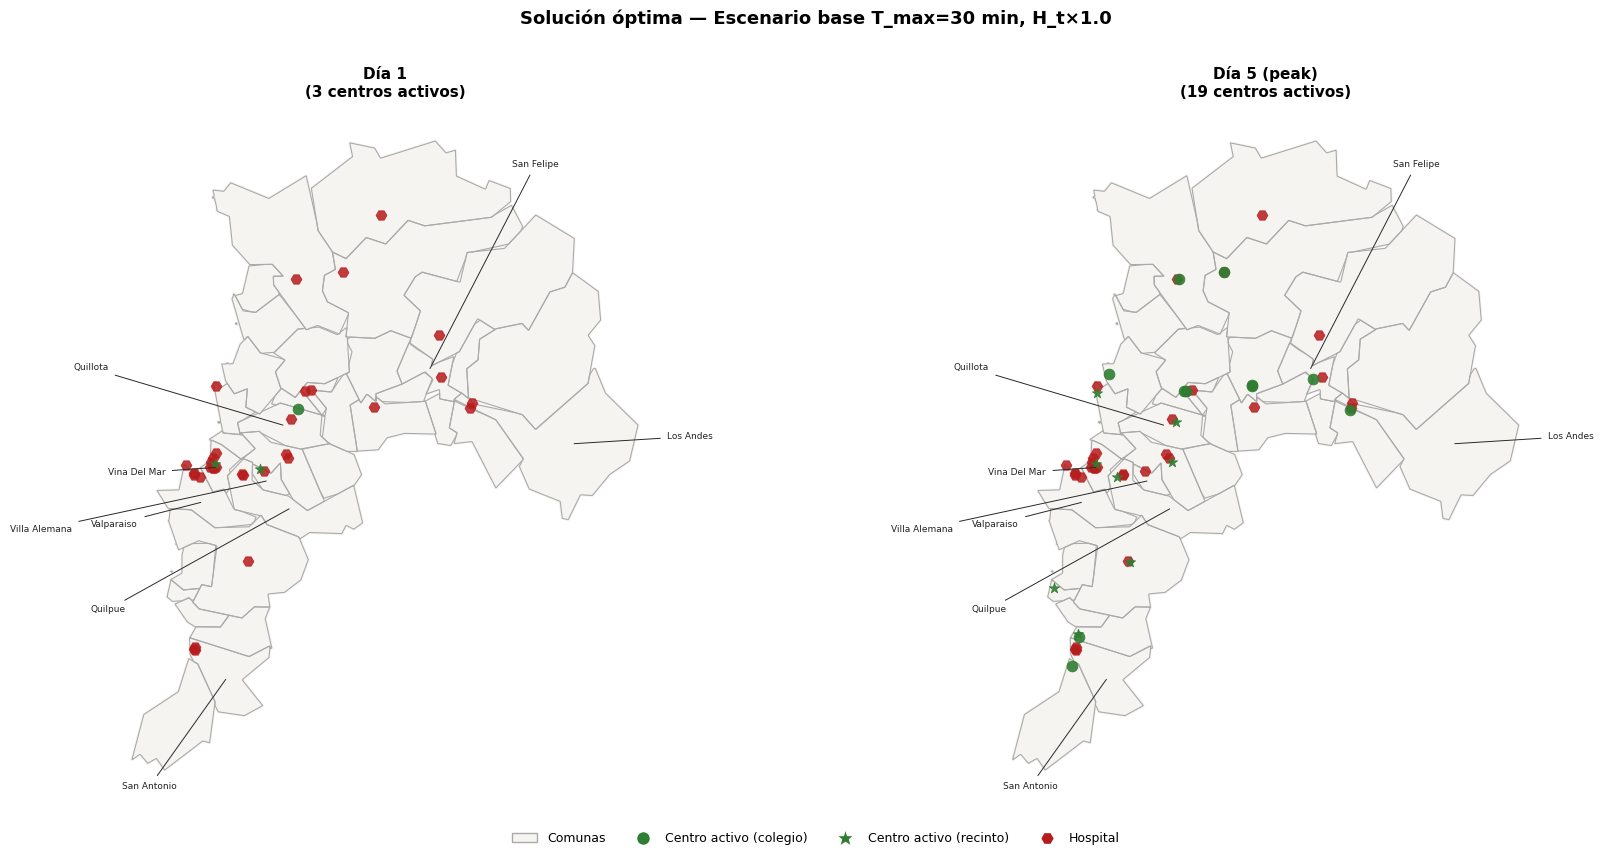

  mapas/02/solucion_dia1_dia5_con_linea.png


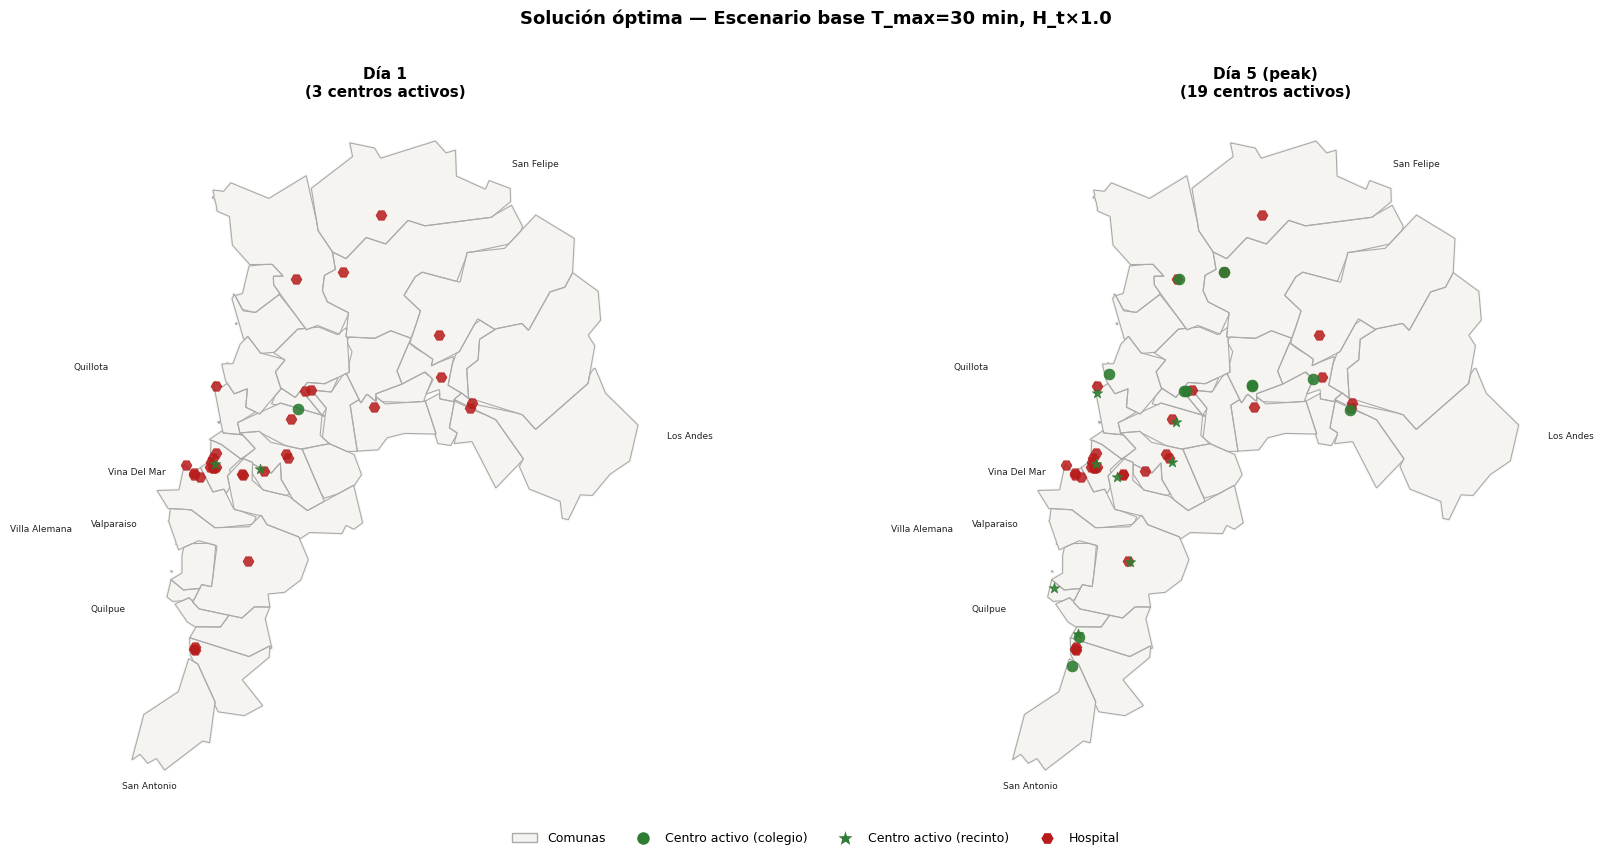

  mapas/02/solucion_dia1_dia5_sin_linea.png


In [268]:
# ── MAPA 2: Solución base T30_H100 (2 versiones: con/sin línea) ──────────────
Path("mapas/02/").mkdir(parents=True, exist_ok=True)

print("Mapa 2: Solución base (Día 1 y Día 5)")
bounds = gdf_comunas.total_bounds


def plot_solucion(ax, df_act, dia, titulo, linea):
    activos_ids = set(df_act[(df_act["t"] == dia) &
                      (df_act["z_jt"] == 1)]["j"])
    n_act = len(activos_ids)

    plot_comunas(ax, gdf_comunas, color=FONDO_COMUNAS)

    activos = gdf_centros[gdf_centros["id"].isin(activos_ids)]

    activos[activos["tipo"] == "colegio"].plot(
        ax=ax, color=COLOR_ACTIVO, marker="o", markersize=MS_ACTIVO,
        alpha=ALPHA_ACTIVO, zorder=Z_CENTRO, linewidth=LW_MARKER)

    activos[activos["tipo"] != "colegio"].plot(
        ax=ax, color=COLOR_ACTIVO, marker="*", markersize=MS_ACTIVO,
        alpha=ALPHA_ACTIVO, zorder=Z_CENTRO, linewidth=LW_MARKER)

    gdf_hosp.plot(ax=ax, color=COLOR_HOSPITAL, marker="H",
                  markersize=MS_HOSPITAL, alpha=ALPHA_HOSPITAL,
                  zorder=Z_HOSPITAL, linewidth=LW_MARKER)

    _add_labels(ax, bounds, linea=linea)

    ax.set_axis_off()
    ax.set_title(f"{titulo}\n({n_act} centros activos)",
                 fontsize=FS_SUBTITLE, fontweight="bold", pad=8)
    return n_act


for linea in (True, False):
    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_2)
    fig.suptitle("Solución óptima — Escenario base T_max=30 min, H_t×1.0",
                 fontsize=FS_SUPTITLE, fontweight="bold", y=1.01)

    plot_solucion(axes[0], df_act_base, dia=1, titulo="Día 1", linea=linea)
    plot_solucion(axes[1], df_act_base, dia=5,
                  titulo="Día 5 (peak)", linea=linea)

    fig.legend(
        handles=[
            mpatches.Patch(facecolor=FONDO_COMUNAS, edgecolor=BORDE_COMUNAS,
                           label="Comunas"),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_ACTIVO,
                       markersize=MS_LEG, markeredgecolor='white', label="Centro activo (colegio)"),
            plt.Line2D([0], [0], marker='*', color='w', markerfacecolor=COLOR_ACTIVO,
                       markersize=MS_LEG_STAR, markeredgecolor='white', label="Centro activo (recinto)"),
            plt.Line2D([0], [0], marker='H', color='w', markerfacecolor=COLOR_HOSPITAL,
                       markersize=MS_LEG, markeredgecolor='white', label="Hospital"),
        ],
        loc="lower center", ncol=4, fontsize=FS_LEGEND, frameon=False,
        borderaxespad=0, bbox_to_anchor=(0.5, -0.04),
    )

    plt.tight_layout()

    ruta = f"mapas/02/solucion_dia1_dia5_{'con' if linea else 'sin'}_linea.png"
    fig.savefig(ruta, dpi=300, bbox_inches="tight", facecolor=FONDO_COMUNAS)
    plt.show()
    plt.close(fig)
    print(f"  {ruta}")

---

## Mapa 3 — Cobertura geográfica: sensibilidad a T_max

> **Uso en informe:** Slide 22 — Análisis de sensibilidad T_max

### Qué muestra

Cómo cambia la cobertura territorial cuando se amplía el radio de tiempo máximo de viaje al PMA, comparando **T_max=30 min** (escenario base) vs **T_max=60 min** (escenario más flexible). Ambos usan H_t×1.0 (mismos recursos) en el peak del día 5.

Una **comuna queda cubierta** si existe al menos un centro activo ese día al que puede llegar en ≤ T_max minutos (según tiempos reales de la matriz T_ij).

### Simbología

| Elemento                 | Qué representa                                                       |
| ------------------------ | -------------------------------------------------------------------- |
| Verde claro (polígono)   | Comuna cubierta: ∃ j activo con T_ij ≤ T_max                         |
| Naranja claro (polígono) | Comuna sin cobertura ese día                                         |
| Círculo azul traslúcido  | Buffer aproximado (radio = T_max × 50 km/h ÷ 60) — referencia visual |
| ● Verde                  | Centro activo en día 5                                               |
| ● Gris                   | Candidato no activo                                                  |

### Ajuste metodológico

Los buffers circulares son **aproximaciones visuales** (velocidad media 50 km/h en línea recta). La cobertura real de comunas se calcula con los tiempos de viaje reales T_ij del modelo, no con el buffer. Los colores de comunas son la fuente de verdad.

### Datos usados

- `tiempos_ij.csv`: tiempos reales de viaje calculados en `construir_instancia.py`.
- `resultado_activacion.csv` de cada escenario para saber qué centros están activos en t=5.

### Interpretación

El aumento de T_max de 30→60 min amplía significativamente la cobertura territorial, especialmente en comunas interiores. Sin embargo, este beneficio geográfico tiene un costo: mayor tiempo de respuesta para los pacientes. Este trade-off es el núcleo del análisis de sensibilidad.


Mapa 3: Cobertura con buffer (T30 vs T60)


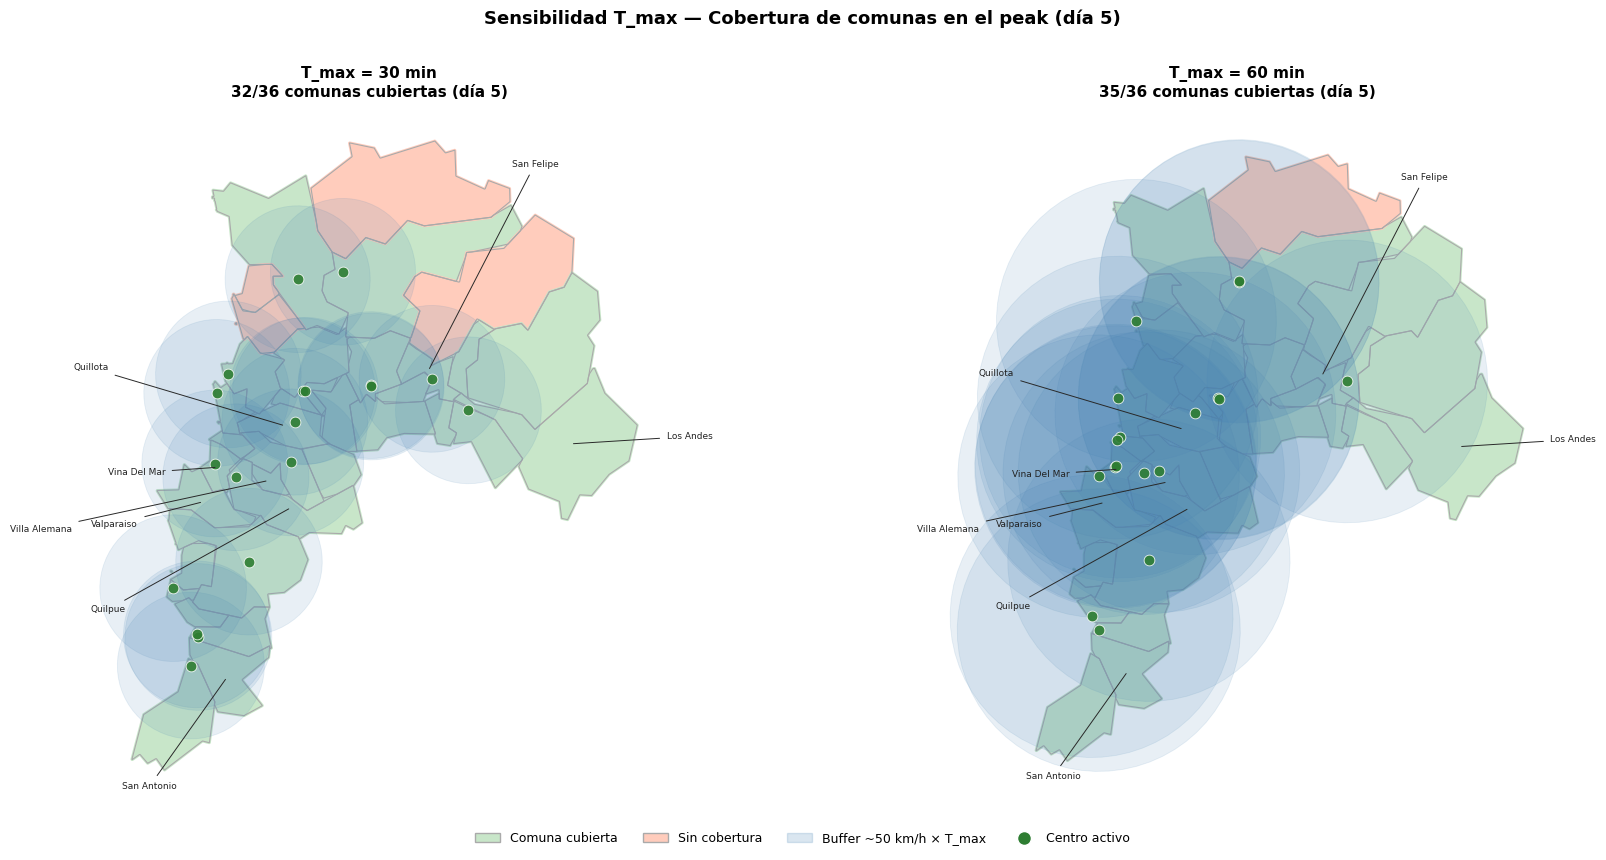

  mapas/03/cobertura_T30_vs_T60_con_linea.png


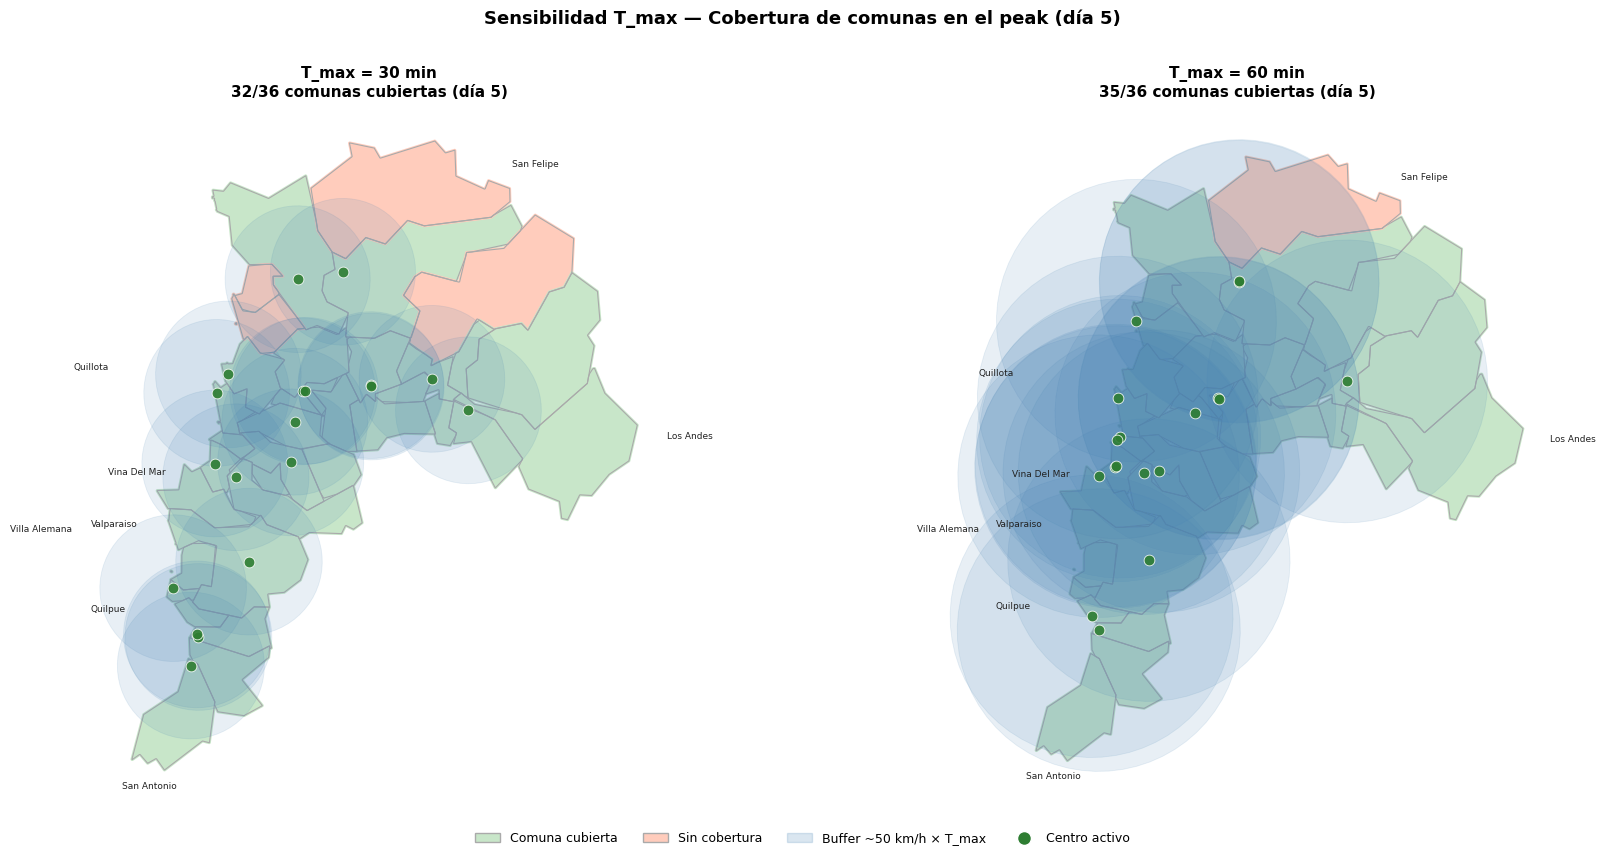

  mapas/03/cobertura_T30_vs_T60_sin_linea.png


In [269]:
# ── MAPA 3: Cobertura con buffer Tmax — T30 vs T60 (2 versiones: con/sin línea)
Path("mapas/03/").mkdir(parents=True, exist_ok=True)

print("Mapa 3: Cobertura con buffer (T30 vs T60)")
CRS_UTM = "EPSG:32719"
VELOCIDAD_KMH = 50
bounds = gdf_comunas.total_bounds


def cobertura_comunas(df_act, dia, tmax_min, df_tiempos):
    activos = set(df_act[(df_act["t"] == dia) & (df_act["z_jt"] == 1)]["j"])
    cob = df_tiempos[(df_tiempos["j"].isin(activos)) &
                     (df_tiempos["minutos"] <= tmax_min)]
    return set(cob["i"])


def plot_cobertura(ax, df_act, tmax_min, titulo, df_tiempos, linea, dia=5):
    activos_ids = set(df_act[(df_act["t"] == dia) &
                      (df_act["z_jt"] == 1)]["j"])
    com_cubiertas = cobertura_comunas(df_act, dia, tmax_min, df_tiempos)

    gdf_plot = gdf_comunas.copy()
    gdf_plot["color"] = gdf_plot["id"].apply(
        lambda i: FONDO_CUBIERTA if i in com_cubiertas else FONDO_SIN_COB)
    plot_comunas(ax, gdf_plot, color=gdf_plot["color"])

    radio_m = tmax_min * VELOCIDAD_KMH * 1000 / 60
    buffers = gdf_centros[gdf_centros["id"].isin(
        activos_ids)].to_crs(CRS_UTM).copy()
    buffers["geometry"] = buffers.geometry.buffer(radio_m)
    buffers.to_crs("EPSG:4326").plot(ax=ax, color=COLOR_BUFFER, alpha=ALPHA_BUFFER,
                                     zorder=Z_BUFFER, edgecolor=COLOR_BUFFER,
                                     linewidth=LW_MARKER)

    gdf_centros[gdf_centros["id"].isin(activos_ids)].plot(
        ax=ax, color=COLOR_ACTIVO, marker="o", markersize=MS_ACTIVO,
        alpha=ALPHA_ACTIVO, zorder=Z_CENTRO, edgecolor='white', linewidth=LW_MARKER)

    _add_labels(ax, bounds, linea=linea)

    ax.set_axis_off()
    ax.set_title(f"{titulo}\n{len(com_cubiertas)}/{len(gdf_comunas)} comunas cubiertas (día {dia})",
                 fontsize=FS_SUBTITLE, fontweight="bold", pad=8)


for linea in (True, False):
    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_2)
    fig.suptitle("Sensibilidad T_max — Cobertura de comunas en el peak (día 5)",
                 fontsize=FS_SUPTITLE, fontweight="bold", y=1.01)

    plot_cobertura(axes[0], df_act_base,    tmax_min=30,
                   titulo="T_max = 30 min", df_tiempos=df_tiempos, linea=linea)
    plot_cobertura(axes[1], df_act_t60h100, tmax_min=60,
                   titulo="T_max = 60 min", df_tiempos=df_tiempos, linea=linea)

    fig.legend(
        handles=[
            mpatches.Patch(facecolor=FONDO_CUBIERTA, edgecolor=BORDE_COMUNAS,
                           label="Comuna cubierta"),
            mpatches.Patch(facecolor=FONDO_SIN_COB,  edgecolor=BORDE_COMUNAS,
                           label="Sin cobertura"),
            mpatches.Patch(facecolor=COLOR_BUFFER, edgecolor=COLOR_BUFFER, alpha=0.2,
                           label=f"Buffer ~{VELOCIDAD_KMH} km/h × T_max"),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_ACTIVO,
                       markersize=MS_LEG, markeredgecolor='white', label="Centro activo"),
        ],
        loc="lower center", ncol=4, fontsize=FS_LEGEND, frameon=False,
        borderaxespad=0, bbox_to_anchor=(0.5, -0.04),
    )

    plt.tight_layout()

    ruta = f"mapas/03/cobertura_T30_vs_T60_{'con' if linea else 'sin'}_linea.png"
    fig.savefig(ruta, dpi=300, bbox_inches="tight", facecolor=FONDO_COMUNAS)
    plt.show()
    plt.close(fig)
    print(f"  {ruta}")

---

## Mapa 4 — Exposición hospitalaria post-sismo

> **Uso en informe:** Slide 3 — "27-F y fragilidad de la red de salud"

### Qué muestra

La **vulnerabilidad diferenciada** de los 32 hospitales de la Región de Valparaíso ante un terremoto Mw≥8. No todos los hospitales operan igual después del sismo: algunos quedan fuera de servicio por inundación tsunami, otros por daño estructural.

### Simbología — Categorías de riesgo

| Color       | Categoría          | Significado operacional                                                  |
| ----------- | ------------------ | ------------------------------------------------------------------------ |
| Rojo oscuro | `tsunami_flood`    | En zona de inundación directa → Cap_t = 0 para todos los días            |
| Rojo        | `tsunami_vertical` | Necesita evacuación vertical → capacidad reducida                        |
| Naranja     | `antiguo_alto`     | Edificio antiguo en cota alta → riesgo estructural, sin tsunami          |
| Amarillo    | `bajo_publico`     | Hospital público en zona de bajo riesgo → opera con degradación moderada |
| Verde       | `privado`          | Clínica privada — generalmente en zonas altas                            |
| Azul        | `moderno_alto`     | Edificio moderno antisísmico en zona alta → mayor resiliencia            |

**Tamaño del hexágono:** proporcional a `camas_base` del hospital.

### Datos usados

- `nodos_hospitales.csv`: categoría asignada en `parametrizar_hospitales.py` cruzando altitud (> 30 m = fuera de zona tsunami), año de construcción y tipo de establecimiento (DEIS/MINSAL).
- `Cap_1..Cap_7`: capacidad por día modelada con degradación gradual (ver Anexo A del informe).

### Interpretación

Una fracción importante de los hospitales costeros queda con Cap=0 por estar en zona de inundación tsunami (`tsunami_flood`). Esto motiva directamente la necesidad de los PMAs: ante la fragilidad de la red hospitalaria, los centros de triaje son la primera línea de atención para heridos leves y moderados.


Mapa 4: Exposición hospitalaria


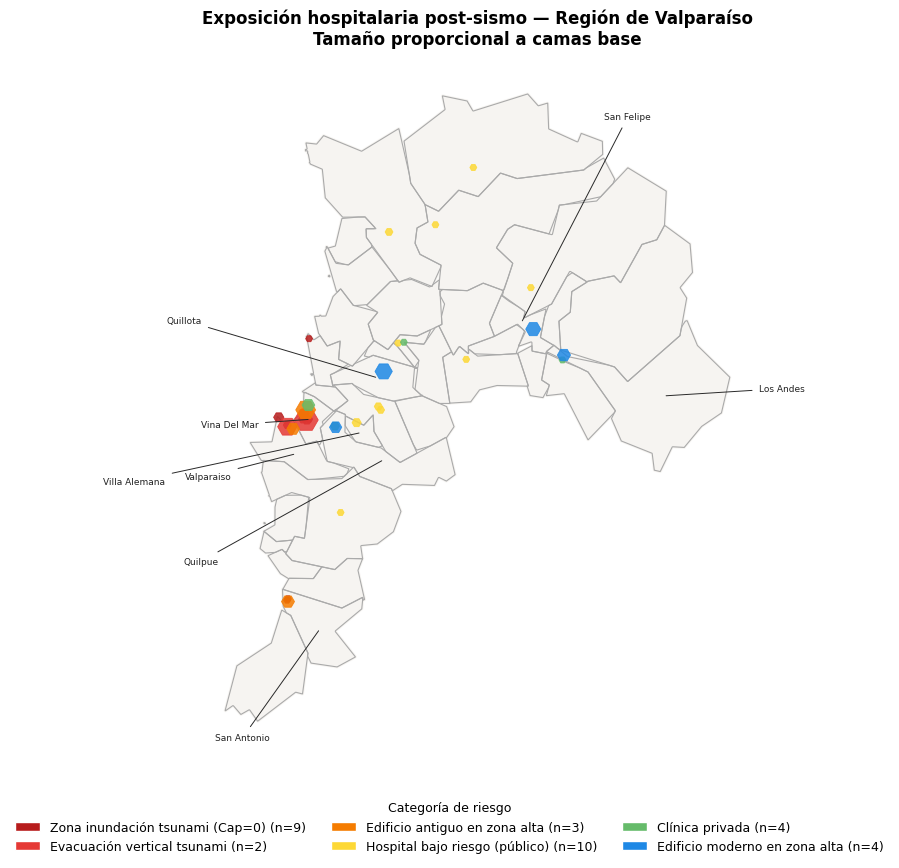

  mapas/04/hospitales_exposicion_con_linea.png


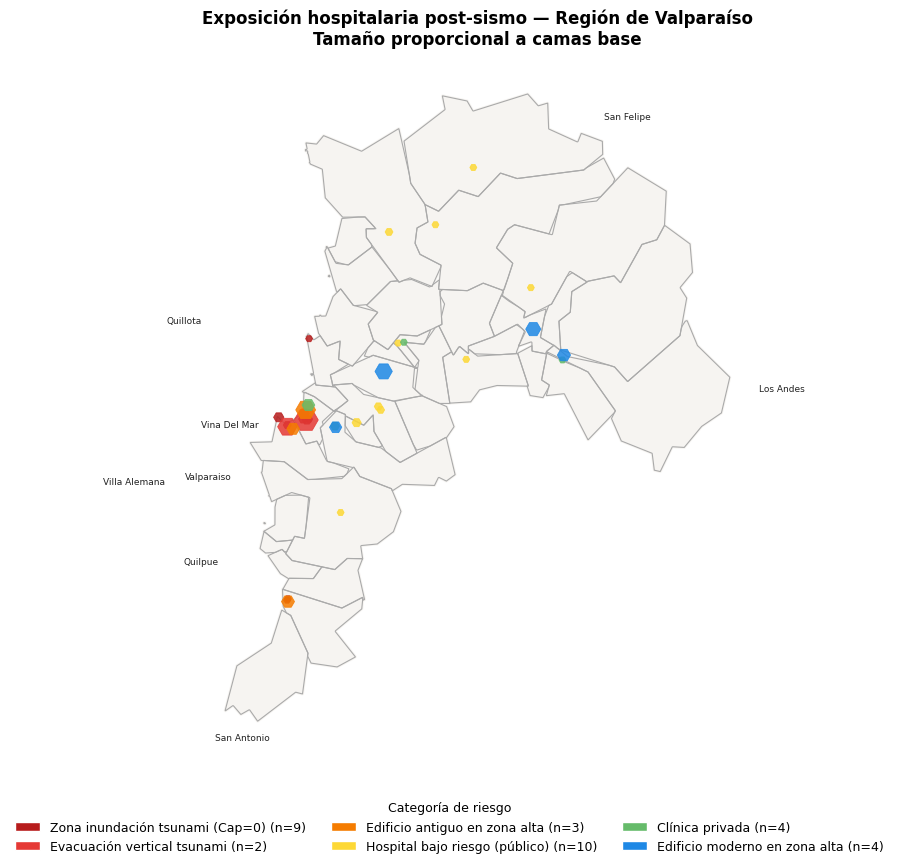

  mapas/04/hospitales_exposicion_sin_linea.png


In [270]:
# ── MAPA 4: Exposición hospitalaria (2 versiones: con/sin línea) ──────────────
Path("mapas/04/").mkdir(parents=True, exist_ok=True)

print("Mapa 4: Exposición hospitalaria")
bounds = gdf_comunas.total_bounds

hosp_leg = [
    mpatches.Patch(facecolor=color, edgecolor='white',
                   label=f"{label} (n={len(gdf_hosp[gdf_hosp['categoria'] == cat])})")
    for cat, (color, label) in CAT_COLORS_HOSP.items()
    if len(gdf_hosp[gdf_hosp["categoria"] == cat]) > 0
]

for linea in (True, False):
    fig, ax = plt.subplots(figsize=FIGSIZE_1)

    plot_comunas(ax, gdf_comunas, color=FONDO_COMUNAS)

    for cat, (color, label) in CAT_COLORS_HOSP.items():
        subset = gdf_hosp[gdf_hosp["categoria"] == cat]
        if len(subset) == 0:
            continue
        sizes = np.clip(subset["camas_base"] / gdf_hosp["camas_base"].max() * MS_HOSP_SCL,
                        MS_HOSP_MIN, MS_HOSP_MAX)
        subset.plot(ax=ax, color=color, marker="H", markersize=sizes.values,
                    alpha=ALPHA_HOSPITAL, zorder=Z_HOSPITAL, linewidth=LW_MARKER)

    _add_labels(ax, bounds, linea=linea)

    ax.set_axis_off()
    ax.set_title("Exposición hospitalaria post-sismo — Región de Valparaíso\nTamaño proporcional a camas base",
                 fontsize=FS_TITLE, fontweight="bold", pad=12)

    ax.legend(
        handles=hosp_leg,
        loc="lower center", bbox_to_anchor=(0.45, -0.15),
        fontsize=FS_LEGEND, frameon=False, borderaxespad=0,
        title="Categoría de riesgo", title_fontsize=FS_LEG_TTL, ncols=3,
    )

    ruta = f"mapas/04/hospitales_exposicion_{'con' if linea else 'sin'}_linea.png"
    fig.savefig(ruta, dpi=300, bbox_inches="tight", facecolor=FONDO_COMUNAS)
    plt.show()
    plt.close(fig)
    print(f"  {ruta}")

---

## Mapa 5 — Zonas sin cobertura: techo geográfico del modelo

> **Uso en informe:** Conclusiones — limitaciones y "techo geográfico"

### Qué muestra

Cuántos centros candidatos son **geográficamente accesibles** desde cada comuna en T_max=30 min, independientemente de la solución óptima. Esto revela el **techo estructural** del modelo: una comuna sin candidatos accesibles nunca podrá ser cubierta sin cambiar los parámetros.

### Simbología

| Color (gradiente)   | Qué significa                                       |
| ------------------- | --------------------------------------------------- |
| Rojo (RdYlGn bajo)  | 0 centros accesibles — comuna sin cobertura posible |
| Amarillo            | Pocos centros accesibles (1–3) — cobertura frágil   |
| Verde (RdYlGn alto) | Muchos centros accesibles — amplia red disponible   |
| Borde rojo grueso   | Comunas con 0 centros accesibles (etiquetadas)      |

### Datos usados

- `cobertura_ij.csv`: generada con T_max=30 min. A_ij=1 indica T_ij ≤ 30 min.
- Se usa la **red completa de candidatos** (85 centros), no solo los activados por el modelo.

### Interpretación

Las comunas en rojo son un límite geográfico duro: ninguna asignación presupuestaria puede cubrirlas con T_max=30 min dado el conjunto actual de candidatos. Para cubrirlas habría que: (a) ampliar T_max, (b) agregar candidatos en esas comunas, o (c) aceptar que dependen exclusivamente de los hospitales. Este mapa fundamenta las recomendaciones de política pública en las conclusiones.


Mapa 5: Zonas sin cobertura óptima


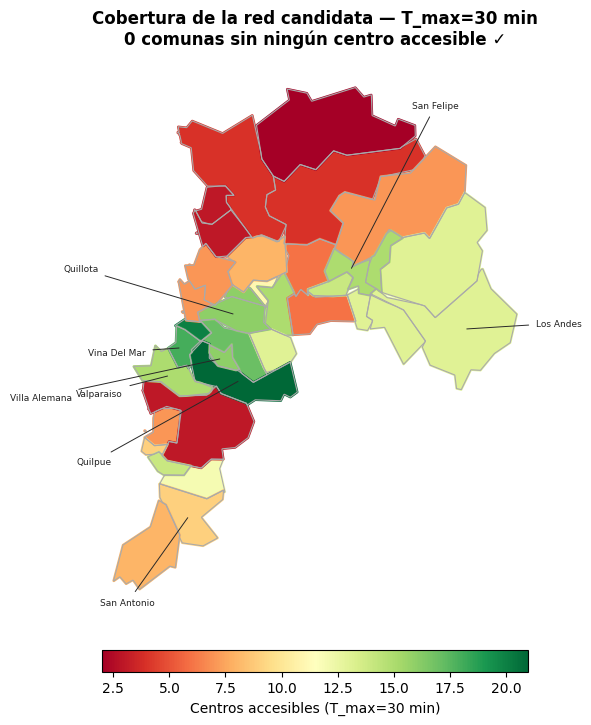

  mapas/05/zonas_sin_cobertura_con_linea.png


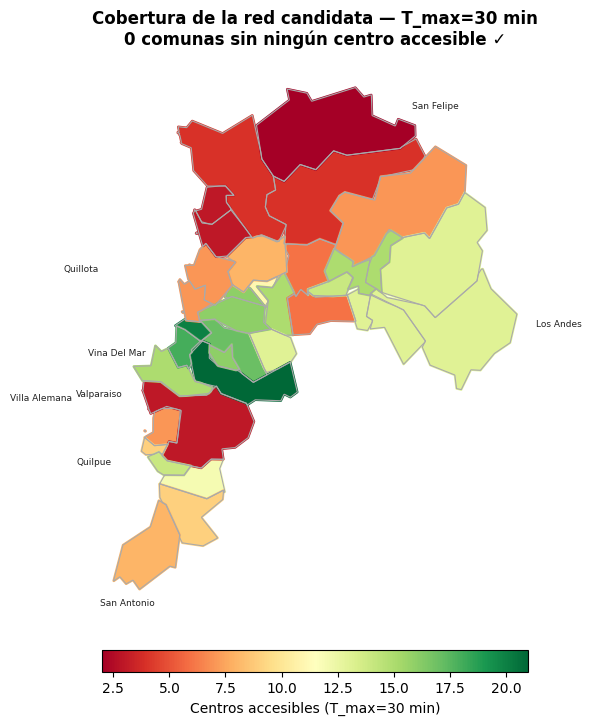

  mapas/05/zonas_sin_cobertura_sin_linea.png


In [271]:
# ── MAPA 5: Zonas sin cobertura óptima (2 versiones: con/sin línea) ────────────
Path("mapas/05/").mkdir(parents=True, exist_ok=True)

print("Mapa 5: Zonas sin cobertura óptima")
bounds = gdf_comunas.total_bounds

centros_por_comuna = (
    df_cob_base[df_cob_base["A_ij"] == 1]
    .groupby("i")["j"].count().reset_index()
    .rename(columns={"i": "id", "j": "n_centros_accesibles"})
)
gdf_cob = gdf_comunas.merge(centros_por_comuna, on="id", how="left")
gdf_cob["n_centros_accesibles"] = gdf_cob["n_centros_accesibles"].fillna(
    0).astype(int)
n_sin_cob = (gdf_cob["n_centros_accesibles"] == 0).sum()
sin_cob_gdf = gdf_cob[gdf_cob["n_centros_accesibles"] == 0]

for linea in (True, False):
    fig, ax = plt.subplots(figsize=FIGSIZE_1)

    plot_comunas(ax, gdf_cob, column="n_centros_accesibles", cmap="RdYlGn", legend=True,
                 legend_kwds={
                     "label": "Centros accesibles (T_max=30 min)",
                     "orientation": "horizontal",
                     "shrink": 0.5,
                     "pad": 0.05,
                 })

    if len(sin_cob_gdf) > 0:
        sin_cob_gdf.plot(ax=ax, facecolor="none",
                         edgecolor=COLOR_UNCOV, linewidth=LW_UNCOV, zorder=Z_CENTRO)

    _add_labels(ax, bounds, linea=linea)

    ax.set_axis_off()
    ax.set_title(
        f"Cobertura de la red candidata — T_max=30 min\n"
        f"{n_sin_cob} comunas sin ningún centro accesible" +
        (" (destacadas con bordes rojos)" if n_sin_cob > 0 else " ✓"),
        fontsize=FS_TITLE, fontweight="bold", pad=12)

    ruta = f"mapas/05/zonas_sin_cobertura_{'con' if linea else 'sin'}_linea.png"
    fig.savefig(ruta, dpi=300, bbox_inches="tight", facecolor=FONDO_COMUNAS)
    plt.show()
    plt.close(fig)
    print(f"  {ruta}")

---

## Mapa 6 — Comparativo de escenarios: base vs óptimo

> **Uso en informe:** Slide 15 — Comparación de escenarios

### Qué muestra

Lado a lado, la distribución geográfica de centros activos en el peak (día 5) para los dos escenarios extremos del análisis:

- **Izquierda — T_max=30 min, H_t×1.0 (base):** Tasa de atención 54,2%. FO=82.857.
- **Derecha — T_max=60 min, H_t×1.5 (óptimo):** Tasa de atención 99,8%. FO=45.925 (−45%).

### Simbología

Igual que Mapa 2: verde = activo, gris = inactivo, rojo = hospital.

### Ajustes comparados

| Parámetro            | Escenario base | Escenario óptimo   |
| -------------------- | -------------- | ------------------ |
| T_max                | 30 min         | 60 min             |
| H_t (día 7)          | 112 equipos    | 168 equipos (+50%) |
| Centros peak (día 5) | 19             | 21                 |
| FO                   | 82.857         | 45.925 (−45%)      |
| Tasa atención d7     | 54,2%          | 99,8%              |

### Interpretación

El incremento en T_max amplía la geografía alcanzable; el incremento en H_t permite atender más pacientes. La combinación de ambos produce la mayor mejora en función objetivo. Sin embargo, ambos tienen costos reales: mayor T_max implica tiempos de respuesta más largos; mayor H_t requiere más personal médico, un recurso escaso en el post-desastre.


Mapa 6: Comparativo de escenarios (Día 5)


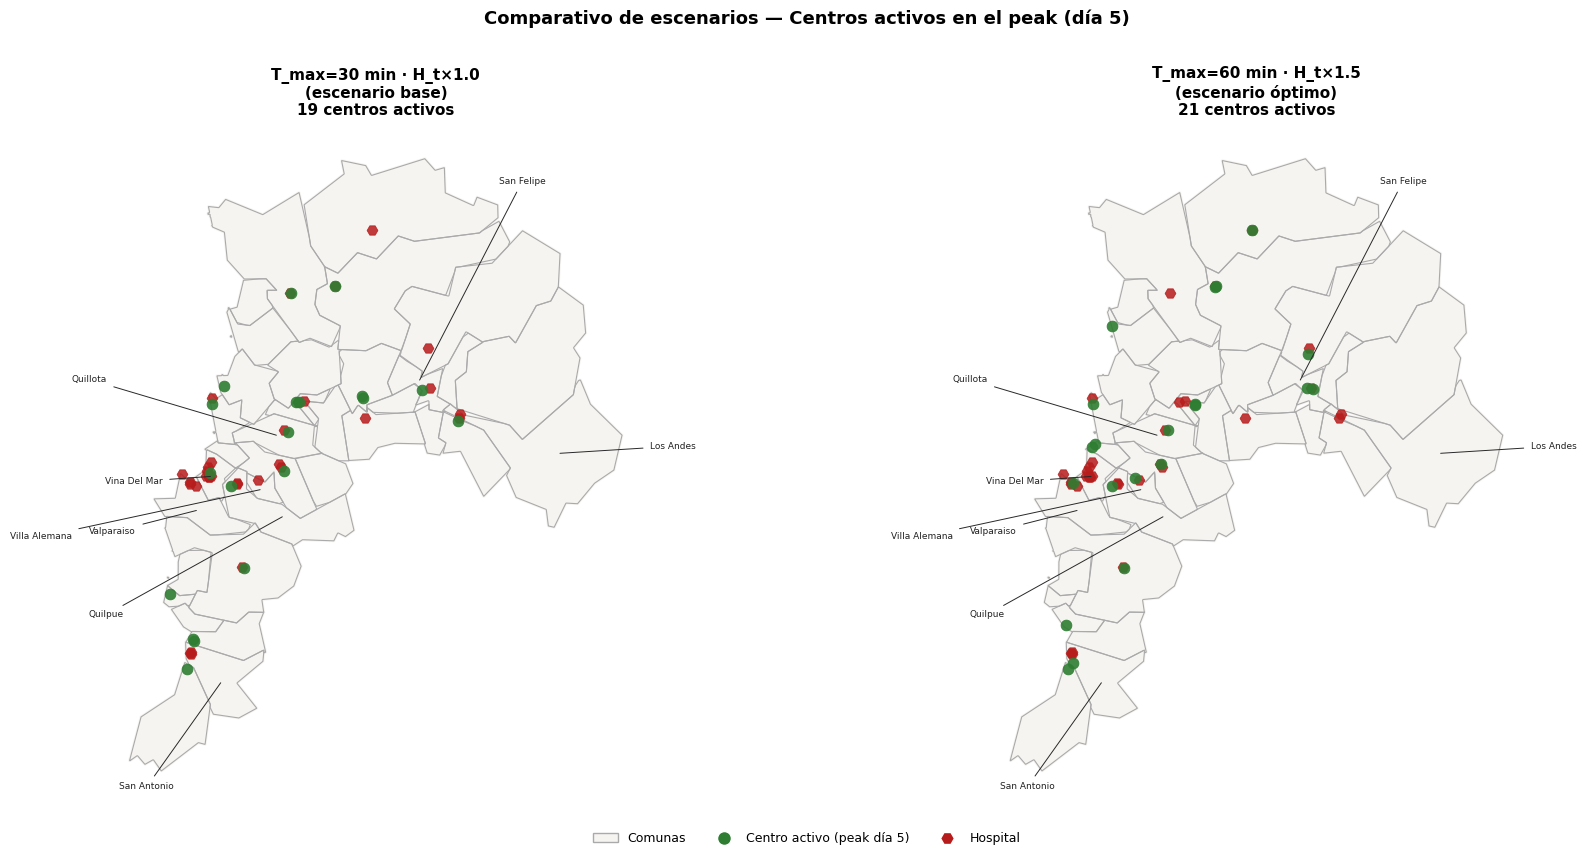

  mapas/06/comparativo_escenarios_con_linea.png


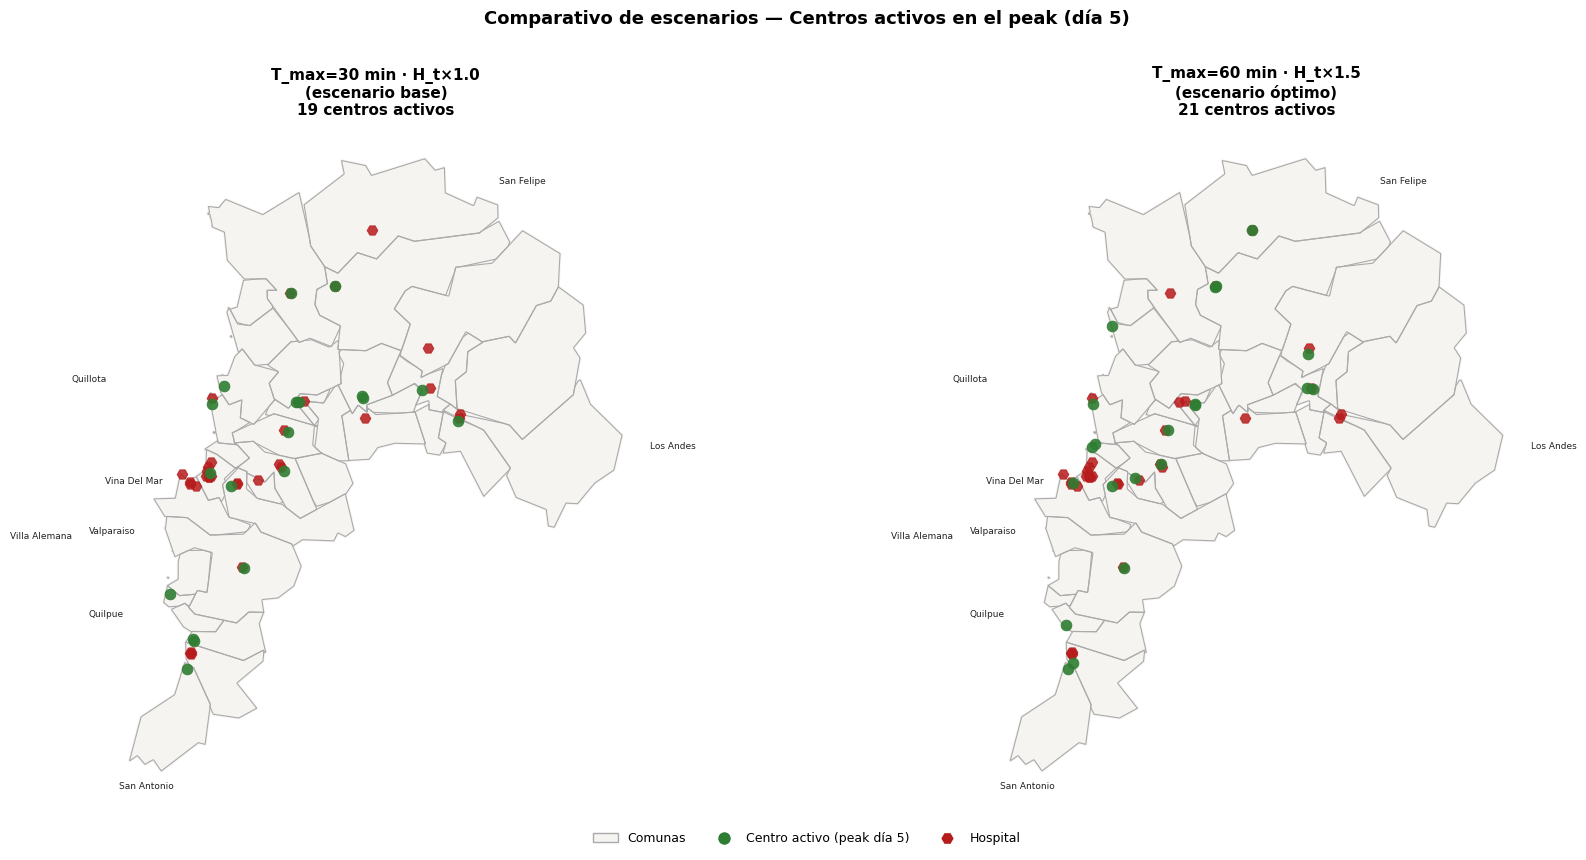

  mapas/06/comparativo_escenarios_sin_linea.png


In [272]:
# ── MAPA 6: Comparativo de escenarios (2 versiones: con/sin línea) ──────────────
Path("mapas/06/").mkdir(parents=True, exist_ok=True)

print("Mapa 6: Comparativo de escenarios (Día 5)")
bounds = gdf_comunas.total_bounds

escenarios = [
    (df_act_base,    "T_max=30 min · H_t×1.0\n(escenario base)"),
    (df_act_t60h150, "T_max=60 min · H_t×1.5\n(escenario óptimo)"),
]

for linea in (True, False):
    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_2)
    fig.suptitle("Comparativo de escenarios — Centros activos en el peak (día 5)",
                 fontsize=FS_SUPTITLE, fontweight="bold", y=1.01)

    for ax, (df_act, titulo) in zip(axes, escenarios):
        activos_ids = set(df_act[(df_act["t"] == 5) &
                          (df_act["z_jt"] == 1)]["j"])

        plot_comunas(ax, gdf_comunas, color=FONDO_COMUNAS)

        gdf_centros[gdf_centros["id"].isin(activos_ids)].plot(
            ax=ax, color=COLOR_ACTIVO, marker="o", markersize=MS_ACTIVO,
            alpha=ALPHA_ACTIVO, zorder=Z_CENTRO, linewidth=LW_MARKER)

        gdf_hosp.plot(ax=ax, color=COLOR_HOSPITAL, marker="H",
                      markersize=MS_HOSPITAL, alpha=ALPHA_HOSPITAL,
                      zorder=Z_HOSPITAL, linewidth=LW_MARKER)

        _add_labels(ax, bounds, linea=linea)

        ax.set_axis_off()
        ax.set_title(f"{titulo}\n{len(activos_ids)} centros activos",
                     fontsize=FS_SUBTITLE, fontweight="bold", pad=8)

    fig.legend(
        handles=[
            mpatches.Patch(facecolor=FONDO_COMUNAS, edgecolor=BORDE_COMUNAS,
                           label="Comunas"),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_ACTIVO,
                       markersize=MS_LEG, markeredgecolor='white',
                       label="Centro activo (peak día 5)"),
            plt.Line2D([0], [0], marker='H', color='w', markerfacecolor=COLOR_HOSPITAL,
                       markersize=MS_LEG, markeredgecolor='white', label="Hospital"),
        ],
        loc="lower center", ncol=3, fontsize=FS_LEGEND, frameon=False,
        borderaxespad=0, bbox_to_anchor=(0.5, -0.04),
    )

    plt.tight_layout()

    ruta = f"mapas/06/comparativo_escenarios_{'con' if linea else 'sin'}_linea.png"
    fig.savefig(ruta, dpi=300, bbox_inches="tight", facecolor=FONDO_COMUNAS)
    plt.show()
    plt.close(fig)
    print(f"  {ruta}")

---

## Mapa 7 — Densidad de demanda estimada

> **Uso en informe:** Slides 2/11 — Contexto e instancia

### Qué muestra

El **volumen de heridos esperados por terremoto Mw≥8** en cada comuna, calculado como `heridos_est = población × τ`. Es el mapa de demanda que alimenta el modelo.

### Cálculo

```
heridos_i = poblacion_i × τ
τ = 0.009 heridos/habitante  (intensidad MMI VIII, Kircher et al.)
```

La demanda total se desagrega en tres gravedades:

- **Leve (66.6%):** ambulatorio, puede llegar al PMA por sus medios.
- **Moderado (23.4%):** requiere atención en PMA dentro de T_max.
- **Grave (10.0%):** requiere hospital; los PMAs no los atienden directamente.

### Datos usados

- `nodos_comunas.csv`: población del Censo 2024 (INE) por comuna.
- `parametros.csv`: τ=0.009, proporciones de gravedad.

### Interpretación

Viña del Mar y Valparaíso concentran la mayor demanda absoluta por ser las comunas más pobladas. Esto explica por qué el modelo tiende a abrir PMAs en el arco costero central. Las comunas interiores (Los Andes, San Felipe) tienen demanda moderada pero poca oferta de candidatos, lo que genera el déficit de cobertura analizado en los Mapas 3 y 5.


Mapa 7: Densidad de demanda


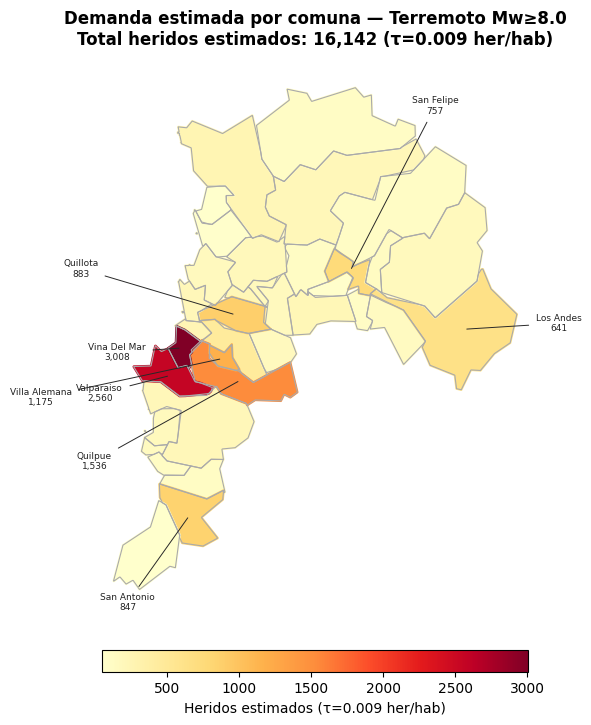

  mapas/07/densidad_demanda_con_linea.png


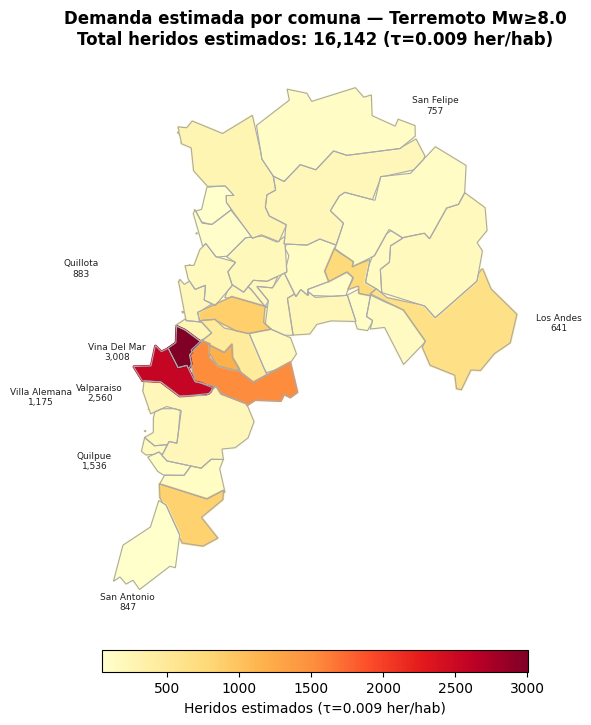

  mapas/07/densidad_demanda_sin_linea.png


In [273]:
# ── MAPA 7: Densidad de demanda (2 versiones: con/sin línea) ──────────────────
Path("mapas/07/").mkdir(parents=True, exist_ok=True)

print("Mapa 7: Densidad de demanda")
bounds = gdf_comunas.total_bounds

TAU = 0.009
gdf_dem = gdf_comunas.copy()
gdf_dem["heridos_est"] = (gdf_dem["poblacion"] * TAU).round().astype(int)
total_heridos = gdf_dem["heridos_est"].sum()

comunas_top_demanda = gdf_dem.nlargest(8, "heridos_est")

for linea in (True, False):
    fig, ax = plt.subplots(figsize=FIGSIZE_1)

    plot_comunas(ax, gdf_dem, column="heridos_est", cmap="YlOrRd", legend=True,
                 legend_kwds={
                     "label": f"Heridos estimados (τ={TAU} her/hab)",
                     "orientation": "horizontal",
                     "shrink": 0.5,
                     "pad": 0.05,
                 })

    for _, row in comunas_top_demanda.iterrows():
        texto_label = f"{row['nombre'].title()}\n{row['heridos_est']:,}"
        _label_fuera(
            ax=ax, name=texto_label, nombre_key=row["nombre"],
            cx=row.geometry.centroid.x, cy=row.geometry.centroid.y,
            bounds=bounds, linea=linea, fontsize=FS_LABEL,
        )

    ax.set_axis_off()
    ax.set_title(
        f"Demanda estimada por comuna — Terremoto Mw≥8.0\n"
        f"Total heridos estimados: {total_heridos:,} (τ={TAU} her/hab)",
        fontsize=FS_TITLE, fontweight="bold", pad=12)

    ruta = f"mapas/07/densidad_demanda_{'con' if linea else 'sin'}_linea.png"
    fig.savefig(ruta, dpi=300, bbox_inches="tight", facecolor=FONDO_COMUNAS)
    plt.show()
    plt.close(fig)
    print(f"  {ruta}")

---

## Resumen de archivos generados

Verifica que los 7 PNGs se hayan guardado correctamente en `mapas/`.


In [274]:
# ── Resumen de archivos generados ──────────────────────────────────────────────
mapas = sorted(Path("mapas").glob("*.png"))
print(f"\n{'='*50}")
print(f"Total mapas generados: {len(mapas)}")
print('='*50)
for p in mapas:
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<35} {size_kb:>7.1f} KB")


Total mapas generados: 12
  01_instancia.png                      369.9 KB
  01b_colegios.png                      385.6 KB
  01b_hospitales.png                    394.3 KB
  01b_instancia_por_tipo.png            964.2 KB
  01b_recintos.png                      362.4 KB
  02_solucion_dia1_dia5.png             654.5 KB
  02b_solucion_por_tipo.png            1359.4 KB
  03_cobertura_T30_vs_T60.png          1204.6 KB
  04_hospitales_exposicion.png          409.4 KB
  05_zonas_sin_cobertura.png            332.3 KB
  06_comparativo_escenarios.png         650.9 KB
  07_densidad_demanda.png               357.6 KB
